## 1. Setup & Imports

In [2]:
from datetime import datetime, timedelta
import time
import os
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ── Path Configuration ────────────────────────────────────────────────
IN_COLAB = True  # Set to True when running on Google Colab

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_ROOT = "/content/drive/MyDrive/CS506/data"
else:
    DATA_ROOT = "../data"

CLEAN_DIR  = f"{DATA_ROOT}/clean"
NEWS_DIR   = f"{DATA_ROOT}/news"
CACHE_DIR  = f"{DATA_ROOT}/sentiment_cache"
MASTER_DIR = f"{DATA_ROOT}/master"

for _d in [CLEAN_DIR, NEWS_DIR, CACHE_DIR, MASTER_DIR]:
    os.makedirs(_d, exist_ok=True)

print(f"Running {'on Colab' if IN_COLAB else 'locally'}")
print(f"Data root: {DATA_ROOT}")

Mounted at /content/drive
Running on Colab
Data root: /content/drive/MyDrive/CS506/data


## 2. Data Acquisition

In [4]:
import pandas as pd
import requests

def fetch_stock(symbol: str, start: datetime, end: datetime, clean_dir: str = "../data/clean"):
    path = f"{clean_dir}/{symbol}_clean.csv"
    if not os.path.exists(path):
        return {"s": "no_data"}

    df = pd.read_csv(path)
    df.rename(columns={"Date": "date"}, inplace=True)
    df["date"] = pd.to_datetime(df["date"])
    df = df[(df["date"] >= start) & (df["date"] < end)]

    if df.empty:
        return {"s": "no_data"}

    return {
        "s": "ok",
        "t": [int(d.timestamp()) for d in df["date"]],
        "c": df["Close"].tolist(),
    }


API_KEY = "d7crg5pr01qv03etebegd7crg5pr01qv03etebf0"

def fetch_news(symbol, start_date, end_date):
    url = f"https://finnhub.io/api/v1/company-news?symbol={symbol}&from={start_date}&to={end_date}&token={API_KEY}"
    response = requests.get(url)
    if response.status_code != 200:
        return []
    return response.json()

In [5]:
from transformers import pipeline

print("Downloading FinBERT ...")
finbert_pipe = pipeline("sentiment-analysis", model="ProsusAI/finbert")

def get_finbert_score(text):
    try:
        if not text or pd.isna(text):
            return 0.0

        result = finbert_pipe(str(text)[:512])[0]

        label = result['label']
        score = result['score']

        if label == 'positive':
            return score
        elif label == 'negative':
            return -score
        else:
            return 0.0

    except Exception as e:
        return 0.0

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [6]:
START_DATE = datetime(2025, 4, 1)
END_DATE   = datetime(2026, 3, 31)
SYMBOLS = [
    "AAPL","AMZN","BAC","CVX","GOOG","GS","HD","JNJ","JPM",
    "MSFT","PFE","TSLA","UNH","XOM"
]

all_stocks_master = []

for symbol in SYMBOLS:
    cache_path = f"{CACHE_DIR}/{symbol}_processed.csv"

    if os.path.exists(cache_path):
        print(f"{symbol} already cached, skipping")
        all_stocks_master.append(pd.read_csv(cache_path))
        continue

    print(f"Processing {symbol} (news + stock + FinBERT) ...")

    try:
        news_path = f"{NEWS_DIR}/{symbol}_news.csv"
        if os.path.exists(news_path):
            df_news = pd.read_csv(news_path)
        else:
            all_news = []
            current = START_DATE
            while current < END_DATE:
                next_date = current + timedelta(days=7)
                news_data = fetch_news(symbol, current.strftime("%Y-%m-%d"), next_date.strftime("%Y-%m-%d"))
                for item in news_data:
                    all_news.append({
                        "date": datetime.fromtimestamp(item["datetime"]).strftime("%Y-%m-%d"),
                        "headline": item.get("headline", ""),
                        "summary": item.get("summary", "")
                    })
                current = next_date
                time.sleep(0.5)

            if not all_news:
                print(f"  {symbol}: no news found, skipping")
                continue

            df_news = pd.DataFrame(all_news)
            df_news.to_csv(news_path, index=False)
            print(f"  Saved {len(df_news)} news rows → {news_path}")

        print(f"  Running FinBERT ...")
        df_news['full_text'] = df_news['headline'].fillna('') + ". " + df_news['summary'].fillna('')
        df_news['sentiment_score'] = df_news['full_text'].apply(get_finbert_score)
        daily_sentiment = df_news.groupby('date')['sentiment_score'].mean().reset_index()

        stock_data = fetch_stock(symbol, START_DATE, END_DATE, clean_dir=CLEAN_DIR)
        if stock_data.get("s") != "ok":
            print(f"  {symbol}: stock data unavailable, skipping")
            continue

        df_stock = pd.DataFrame({
            "date": [datetime.fromtimestamp(t).strftime("%Y-%m-%d") for t in stock_data["t"]],
            "close": stock_data["c"]
        })

        df_final = pd.merge(df_stock, daily_sentiment, on="date", how="left").fillna(0)
        df_final["label"] = df_final["close"].diff().fillna(0).apply(lambda x: 1 if x > 0 else 0)
        df_final['sentiment_score_shifted'] = df_final['sentiment_score'].shift(1)
        df_final["symbol"] = symbol
        df_final = df_final.dropna()

        df_final.to_csv(cache_path, index=False)
        all_stocks_master.append(df_final)
        print(f"  {symbol} done, saved to cache")

    except Exception as e:
        print(f"  {symbol} error: {e}")

if all_stocks_master:
    mega_df = pd.concat(all_stocks_master, axis=0, ignore_index=True)
    mega_df.to_csv(f"{MASTER_DIR}/Mega_Stock_Dataset_Final.csv", index=False)
    print("\n" + "="*40)
    print(f"All done. {len(all_stocks_master)} stocks processed.")
    print(f"Total rows: {len(mega_df)}")
    print("="*40)

AAPL already cached, skipping
AMZN already cached, skipping
BAC already cached, skipping
CVX already cached, skipping
GOOG already cached, skipping
GS already cached, skipping
HD already cached, skipping
JNJ already cached, skipping
JPM already cached, skipping
MSFT already cached, skipping
PFE already cached, skipping
TSLA already cached, skipping
UNH already cached, skipping
XOM already cached, skipping

All done. 14 stocks processed.
Total rows: 3192


## 3. Feature Extraction

In [7]:
all_stocks_master = []

for symbol in SYMBOLS:
    cache_path = f"{CACHE_DIR}/{symbol}_mega_features.csv"

    if os.path.exists(cache_path):
        all_stocks_master.append(pd.read_csv(cache_path))
        continue

    print(f"Processing {symbol} ...")

    try:
        q_path = f"{CLEAN_DIR}/{symbol}_clean.csv"
        if not os.path.exists(q_path):
            print(f"  {symbol}_clean.csv not found, skipping")
            continue

        df_rich = pd.read_csv(q_path)
        df_rich.rename(columns={'Date': 'date'}, inplace=True)
        df_rich['date'] = pd.to_datetime(df_rich['date']).dt.strftime('%Y-%m-%d')

        merged = pd.merge(df_rich, daily_sentiment, on="date", how="left").fillna(0)

        cols_to_lag = ['Volume', 'Return', 'Market_Return', 'Excess_Return', 'Corr_30', 'Beta_30', 'sentiment_score']
        for col in cols_to_lag:
            if col in merged.columns:
                merged[f'{col}_lag1'] = merged[col].shift(1)

        merged["symbol"] = symbol
        merged = merged.dropna()

        merged.to_csv(cache_path, index=False)
        all_stocks_master.append(merged)
        print(f"  {symbol} merging complete")

    except Exception as e:
        print(f"  {symbol} failed: {e}")

if all_stocks_master:
    mega_df = pd.concat(all_stocks_master, axis=0, ignore_index=True)

    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    mega_df['symbol_id'] = le.fit_transform(mega_df['symbol'])

    mega_df.to_csv(f"{MASTER_DIR}/Final_Mega_Dataset.csv", index=False)
    print("\n" + "="*40)
    print(f"Done. Merged {len(all_stocks_master)} stocks.")
    print(f"Final dataset: {len(mega_df)} rows x {len(mega_df.columns)} columns")
    print("="*40)


Done. Merged 14 stocks.
Final dataset: 3388 rows x 25 columns


## 4. Model Training

In [8]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
import plotly.express as px

df_mega = pd.read_csv(f"{MASTER_DIR}/Final_Mega_Dataset.csv")
if 'label' not in df_mega.columns:
    df_mega['label'] = (df_mega['Return'] > 0).astype(int)

df_mega = df_mega.dropna()

features = [
    'Volume_lag1', 'Return_lag1', 'Market_Return_lag1',
    'Excess_Return_lag1', 'Corr_30_lag1', 'Beta_30_lag1',
    'sentiment_score_lag1', 'symbol_id'
]

X = df_mega[features]
y = df_mega['label']

split_idx = int(len(df_mega) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 2710, Test size: 678


In [9]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline Accuracy: {accuracy:.2%}")
print(classification_report(y_test, y_pred))

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=True)

fig = px.bar(
    importance_df,
    x='Importance',
    y='Feature',
    orientation='h',
    title="Baseline Model: Feature Importance",
    color='Importance',
    color_continuous_scale='Portland'
)
fig.update_layout(template='plotly_dark')
fig.show()

Baseline Accuracy: 55.16%
              precision    recall  f1-score   support

           0       0.53      0.46      0.49       318
           1       0.57      0.63      0.60       360

    accuracy                           0.55       678
   macro avg       0.55      0.55      0.55       678
weighted avg       0.55      0.55      0.55       678



## 5. Hyperparameter Tuning

In [10]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
}

cv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(
    xgb.XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.2%}")

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'colsample_bytree': 0.9, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.9}
Best CV accuracy: 58.36%


## 6. Evaluation

In [11]:
y_pred_best = best_model.predict(X_test)
accuracy_best = accuracy_score(y_test, y_pred_best)

print(f"Best Model Accuracy: {accuracy_best:.2%}")
print(classification_report(y_test, y_pred_best))

importance_df_best = pd.DataFrame({
    'Feature': features,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=True)

fig = px.bar(
    importance_df_best,
    x='Importance',
    y='Feature',
    orientation='h',
    title="Best Model: Feature Importance",
    color='Importance',
    color_continuous_scale='Portland'
)
fig.update_layout(template='plotly_dark')
fig.show()

Best Model Accuracy: 56.64%
              precision    recall  f1-score   support

           0       0.54      0.46      0.50       318
           1       0.58      0.66      0.62       360

    accuracy                           0.57       678
   macro avg       0.56      0.56      0.56       678
weighted avg       0.56      0.57      0.56       678



In [12]:
!pip install shap

In [13]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values_target = shap_values[1]
else:
    shap_values_target = shap_values

>>> SHAP 全局特征重要性与影响方向 (蜂群图)


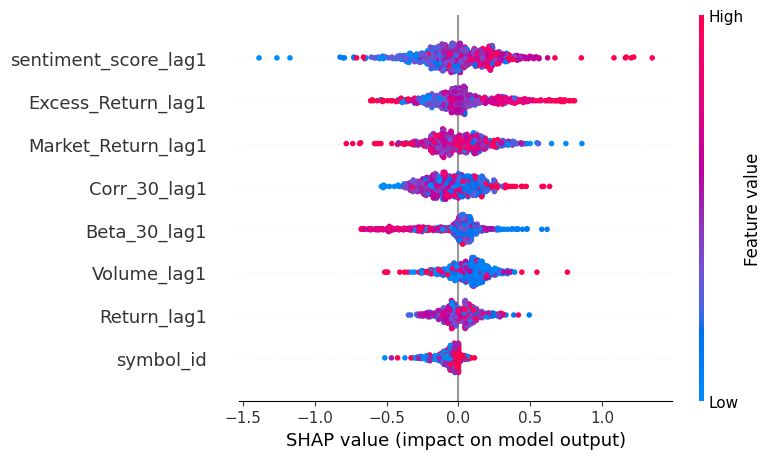

In [18]:
# 绘制蜂群图 (Beeswarm Plot)
print(">>> SHAP 全局特征重要性与影响方向 (蜂群图)")
shap.summary_plot(shap_values_target, X_test)
'''
X 轴（SHAP 值）： 代表特征对预测结果的影响方向和力度。
中心 0 轴以右（正值）： 把预测结果往“1”（股票上涨）的方向推。
中心 0 轴以左（负值）： 把预测结果往“0”（股票下跌）的方向推。越靠两边，力度越大。
颜色（红与蓝）： 代表特征本身的数值大小。红色代表该特征的值很高，蓝色代表该特征的值很低。
推的越厉害说明影响力度越大
'''

>>> SHAP 特征依赖图 (sentiment_score_lag1)


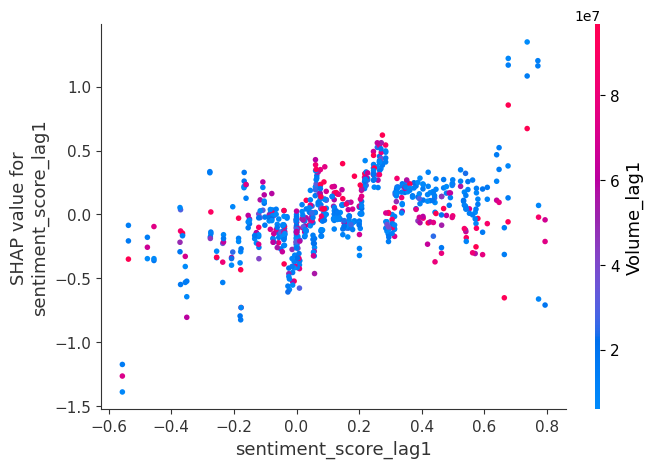

In [15]:
# 绘制依赖图 (以 sentiment_score_lag1 为例)
print(">>> SHAP 特征依赖图 (sentiment_score_lag1)")
shap.dependence_plot("sentiment_score_lag1", shap_values_target, X_test)
'''
X轴：新闻是正面还是负面
Y轴：值越大代表越应该去买，越小越不应该去买
蓝色：昨日交易量小
红色：昨日交易量大
'''

>>> SHAP 单个样本预测解释 (瀑布图)


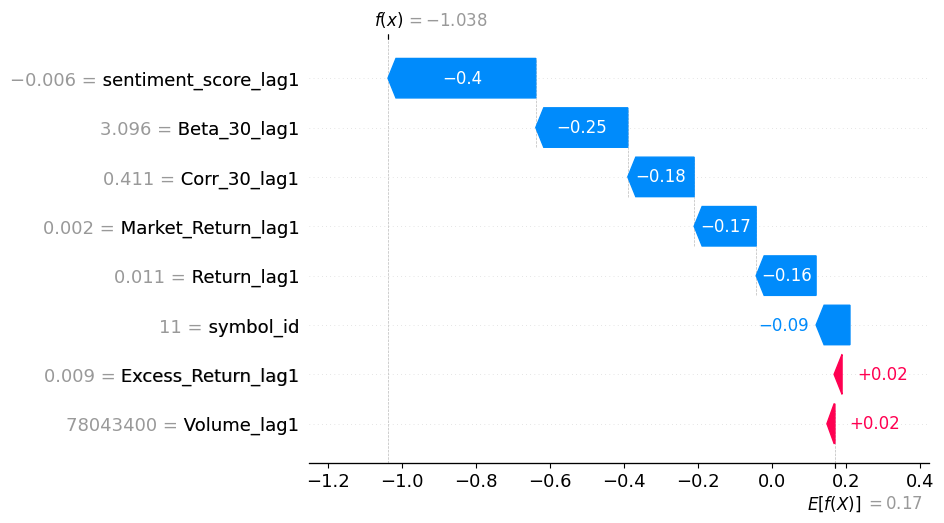

'\n单个样本的看涨跌概率变化图\neg：平均一支股票的认为是上涨的基础概率是17%\n红色代表对这个股票看涨的正向数值，也就是要加在原始基础概率上的数值\n蓝色代表对这个股票看涨的反向数值，也就是要减去原始基础概率上的数值\n最终得到的数值就是这个股票被看涨看跌的概率\n'

In [22]:
import matplotlib.pyplot as plt

print(">>> SHAP 单个样本预测解释 (瀑布图)")
explainer_v2 = shap.Explainer(best_model)
shap_values_v2 = explainer_v2(X_test)

sample_index = 1
shap.plots.waterfall(shap_values_v2[sample_index])
'''
单个样本的看涨跌概率变化图
eg：平均一支股票的认为是上涨的基础概率是17%
红色代表对这个股票看涨的正向数值，也就是要加在原始基础概率上的数值
蓝色代表对这个股票看涨的反向数值，也就是要减去原始基础概率上的数值
最终得到的数值就是这个股票被看涨看跌的概率
'''

In [1]:
!apt-get install graphviz -y
!pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


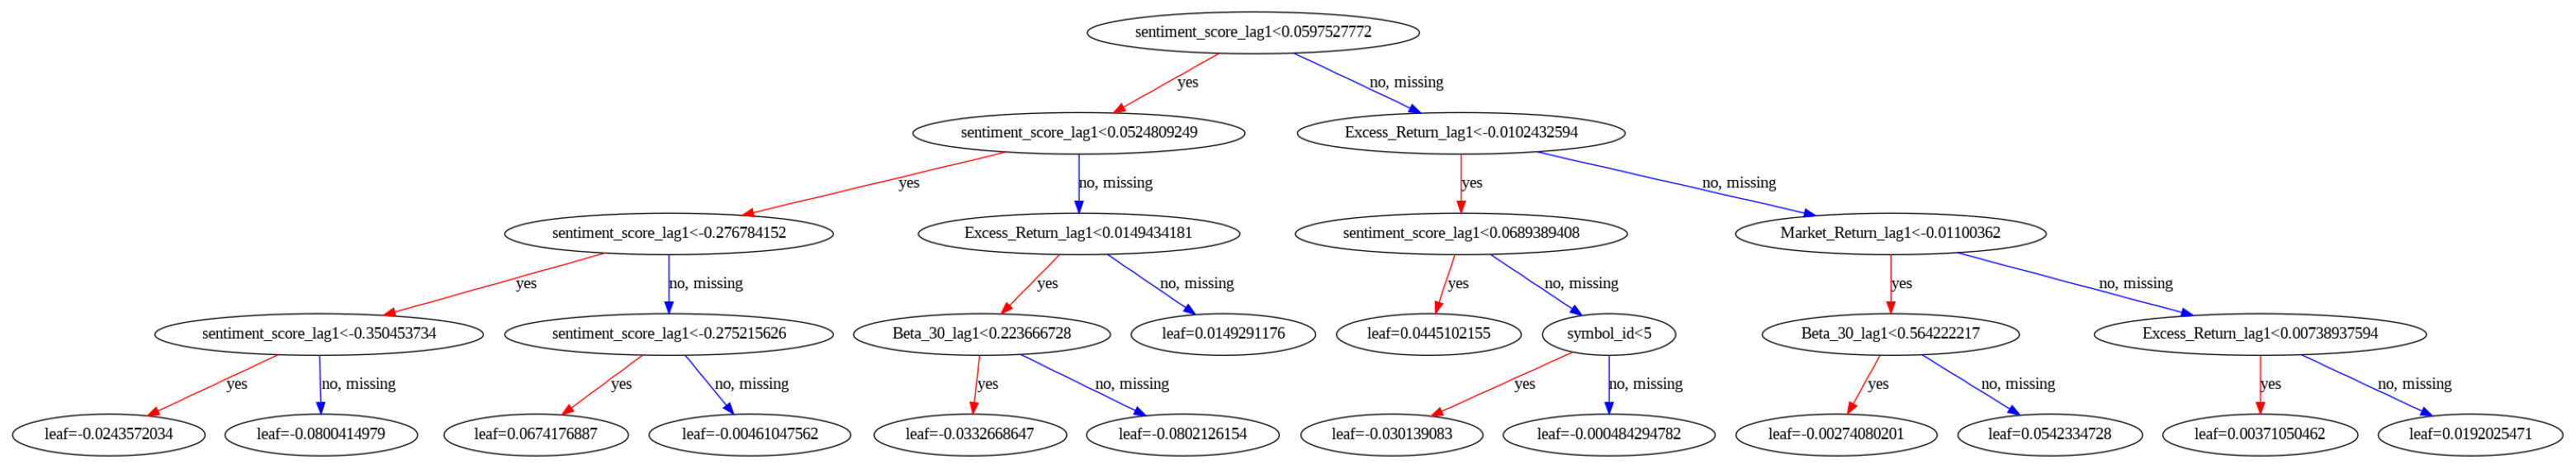

In [17]:
import matplotlib.pyplot as plt
from xgboost import plot_tree

fig, ax = plt.subplots(figsize=(40, 30))

plot_tree(best_model, num_trees=0, ax=ax, rankdir='TB')

plt.show()